# IFB 02 — Input Validation

Check recent-demand completeness and operational weather coverage before inference.

In [1]:
# Import libraries
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define config paths
PROJECT_ROOT = Path.cwd()
while (
    not (PROJECT_ROOT / "src").exists()
    and PROJECT_ROOT != PROJECT_ROOT.parent
):
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = (
    PROJECT_ROOT
    / "configs"
    / "inference_feature_builder.yaml"
)

print("Project root:", PROJECT_ROOT)
print("IFB config:", CONFIG_PATH)


Project root: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk
IFB config: e:\jcuenca\OneDrive - GUSCanada\5toTerm\01_Capstone\DataLocal\ontario-electricity-peak-risk\configs\inference_feature_builder.yaml


In [3]:
# Import module for running inference_feature_builder
from src.ontario_peak_risk.inference_feature_builder.io import (
    load_ifb_config,
    load_operational_updates,
    load_project_history,
    combine_observed_history,
    latest_weather_forecast_for_origin,
)
from src.ontario_peak_risk.inference_feature_builder.validation import (
    demand_history_requirements,
    validate_weather_grid,
)
from src.ontario_peak_risk.inference_feature_builder.plotting import (
    demand_recency_plot,
    missing_demand_plot,
    weather_coverage_plot,
)


### Define the Origin Time for forecasting
- This is the date from which consumption for the next 24 hours is forecasted.
- This value must be changed according with the requirement

In [4]:
# Define the Origin time
Origin_Time = "2026-03-25 23:00:00"

### Validate required information
- Verify that there are previous consumption records
- Check that there are weather forecasts

In [5]:
# Load available data
config, project_root = load_ifb_config(CONFIG_PATH)

# Recovery data
FORECAST_ORIGIN = pd.Timestamp(Origin_Time)
FSAS = list(config["inference"]["fsas"])

project_history = load_project_history(config, project_root)
updates = load_operational_updates(config, project_root)

observed_history, duplicate_report = combine_observed_history(
    project_history,
    updates["demand"],
    updates["weather_history"],
    config,
)

forecast_weather = latest_weather_forecast_for_origin(
    updates["weather_forecasts"],
    FORECAST_ORIGIN,
    FSAS,
    config,
)

demand_coverage, missing_demand = demand_history_requirements(
    observed_history,
    FORECAST_ORIGIN,
    FSAS,
    config,
)

weather_coverage, missing_weather = validate_weather_grid(
    forecast_weather,
    FORECAST_ORIGIN,
    FSAS,
    config,
)



In [6]:
# Display Demand coverage by FSA
display(demand_coverage)

,fsa,required_start,required_end,required_hours,available_hours,missing_hours,latest_available_demand,gap_from_latest_to_origin_hours,status
0,L4T,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
1,M5R,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
2,M5S,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
3,M6G,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
4,M9R,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS
5,M9W,2026-03-18 23:00:00,2026-03-25 23:00:00,169,169,0,2026-03-25 23:00:00,0.0,PASS


In [7]:
# Show missing values for demand
if not missing_demand.empty:
    display(missing_demand.head(30))
else:
    print("No missing demand values")

No missing demand values


In [8]:
# Display weather coverage by FSA
display(weather_coverage)

,fsa,required_rows_h0_h24,available_complete_rows,missing_rows,status
0,L4T,25,25,0,PASS
1,M5R,25,25,0,PASS
2,M5S,25,25,0,PASS
3,M6G,25,25,0,PASS
4,M9R,25,25,0,PASS
5,M9W,25,25,0,PASS


In [9]:
# Show missing values for weather
if not missing_weather.empty:
    display(missing_weather.head(30))
else:
    print("No missing weather values")


No missing weather values


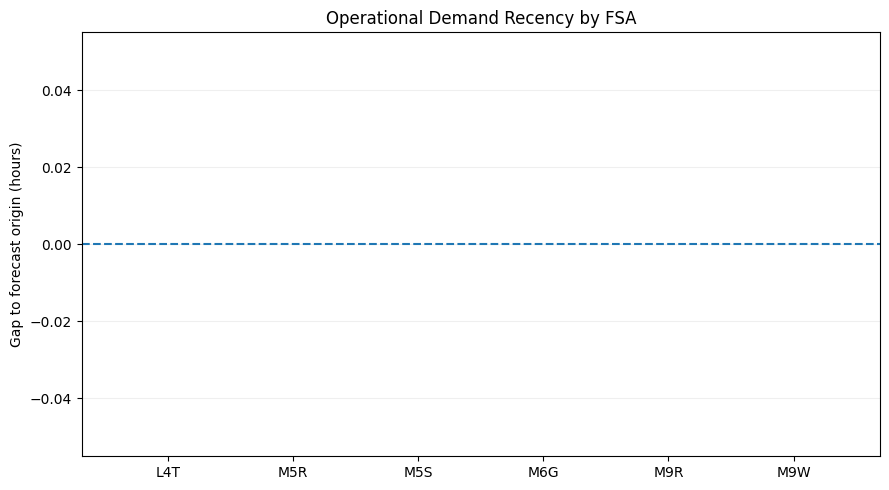

In [10]:
# Demand coverage
demand_recency_plot(demand_coverage)
plt.show()

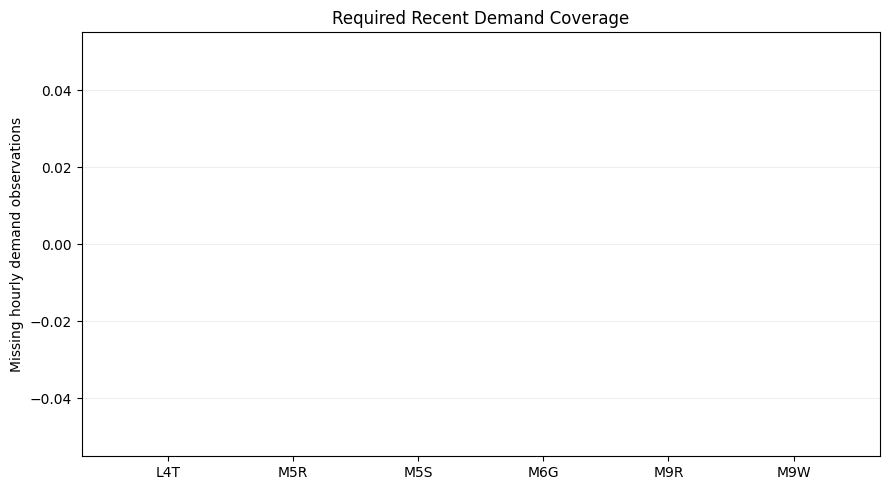

In [11]:
# Missing demand coverage
missing_demand_plot(demand_coverage)
plt.show()

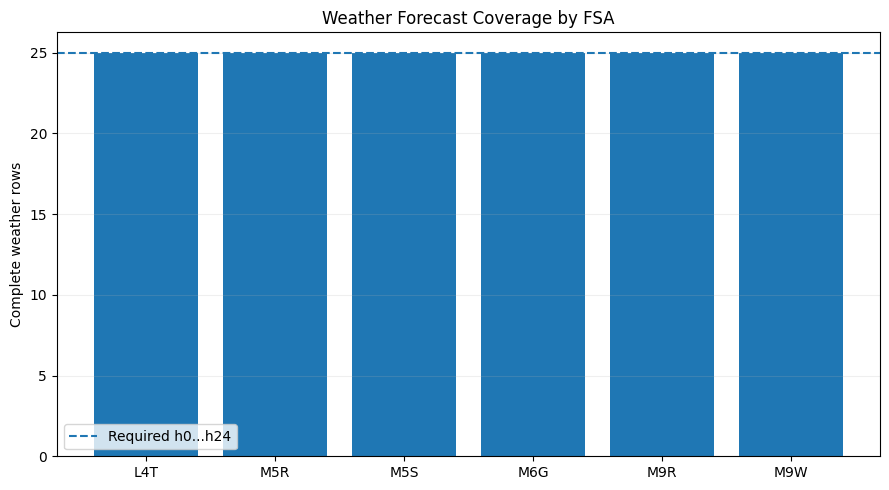

In [12]:
# Weather coverage
weather_coverage_plot(weather_coverage)
plt.show()



A missing month is **not** filled. If the complete recent observed-demand
window is unavailable, true operational inference should stop and report the
missing timestamps.
